In [1]:
import sys
sys.path.append("../")  # Goes up to "project/"
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_binary_conf(NX,NT,path):
    """
    Function used for opening a gauge configuration in binary format.
    It can also be used to open a .tv file with a test vector, necessary
    for training.
    """
    N = 2*NX*NT
    x, t, mu, vals = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N,dtype=complex)
    #U[μ,t,x]
    #conf = np.zeros((2,var.NT,var.NX),dtype=complex)
    data = np.fromfile(path, dtype=[('x', 'i4'),
                ('t', 'i4'),
                ('mu', 'i4'),
                ('re','f8'),
                ('im','f8')])
    conf = np.zeros((2, NT, NX), dtype=np.complex128)
    conf[data['mu'], data['t'], data['x']] = data['re'] + 1j * data['im']            
    return conf

In [3]:
beta, N, m0_str = 2, 32, "-01884"
nconf = 0
tv = 0 
NV = 20
test_vectors = np.zeros((NV,N*N),dtype=complex)
for tv in range(NV):
    path = "../real_tv/b{0}_{1}x{1}/m-018/tvector_{1}x{1}_b{0}0000_m{2}_nconf{3}_tv{4}.tv".format(
        beta, N, m0_str, nconf, tv
        )
    test_vector = read_binary_conf(N,N,path)
    flatten_vector_spin0 = test_vector[0].flatten()
    test_vectors[tv] = flatten_vector_spin0

[[0.10337712 0.11275108 0.08112966 ... 0.08343031 0.12414798 0.16170665]
 [0.0416576  0.080646   0.09173747 ... 0.02132537 0.04640852 0.04969485]
 [0.07314098 0.10609612 0.1172936  ... 0.01610122 0.06612421 0.04006243]
 ...
 [0.22477754 0.21348245 0.21965809 ... 0.30448118 0.23993628 0.22730153]
 [0.20168559 0.21867728 0.22681919 ... 0.12143941 0.16649741 0.20460883]
 [0.17163521 0.16833035 0.20344714 ... 0.10982014 0.20613366 0.2458057 ]]


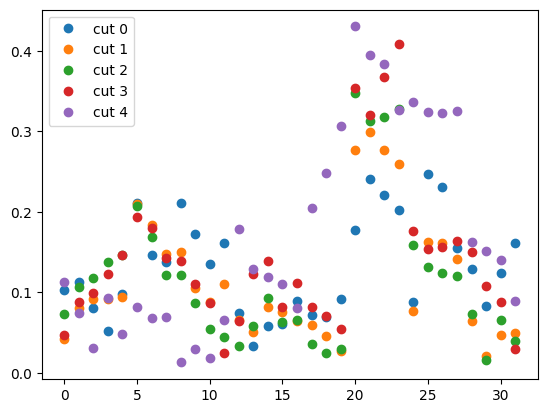

In [4]:
print(np.abs(test_vector[0]))
X = np.arange(0,32,1)
for i in range(5):
    cut1 = np.abs(test_vector[0,i])
    plt.plot(X,cut1,marker='o',linestyle='',label='cut {0}'.format(i))
plt.legend()

In [5]:
U, s, Vh = np.linalg.svd(test_vectors, full_matrices=True, compute_uv=True, hermitian=False)

In [11]:
Vh.shape

(1024, 1024)